# IEEE-CIS Fraud Detection — Exploratory Data Analysis

## Business Context

Card-not-present (CNP) fraud occurs when a fraudster uses stolen card details 
to make online purchases without physically having the card. It is one of the 
fastest growing forms of financial crime.

**The cost of getting this wrong:**
- False Negative (missed fraud) → ~$250 average loss per transaction
- False Positive (blocking legitimate transaction) → ~$5 customer friction cost
- This asymmetry directly influences our choice of model threshold

**Why this is hard:**
- Fraud is rare (~3.5% of transactions) — severe class imbalance
- Fraudsters constantly adapt their behaviour — concept drift
- Features are partially masked — requires careful feature analysis

**Our goal:** Build a model that maximises fraud caught while minimising 
disruption to legitimate customers — optimised using a business cost matrix,
not just accuracy.

## Chapter 2 — Data Quality Investigation

Before building any model, we need to understand the quality of our data.
Poor quality data leads to poor models — garbage in, garbage out.

We investigate three things:
1. **Missingness** — which columns have nulls and is the pattern meaningful?
2. **Duplicates** — are there any duplicate transactions?
3. **Data types** — are columns the right type for analysis?

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries loaded successfully")

In [14]:
os.chdir("/Users/shaliqshukoor/fraud-risk-system")
train_transactions=pd.read_csv("data/raw/train_transaction.csv") 
train_identity = pd.read_csv("data/raw/train_identity.csv")
print("Data loaded successfully")
print("Transactions shape:", train_transactions.shape)
print("Identity shape:", train_identity.shape)

Data loaded successfully
Transactions shape: (590540, 394)
Identity shape: (144233, 41)


## Transaction Table

| Column | Description |
|--------|-------------|
| `TransactionDT` | Timedelta from a given reference datetime (not an actual timestamp) |
| `TransactionAMT` | Transaction payment amount in USD |
| `ProductCD` | Product code for each transaction |
| `card1` – `card6` | Payment card information (card type, category, issuing bank, country, etc.) |
| `addr` | Address |
| `dist` | Distance |
| `P_emaildomain` | Purchaser email domain |
| `R_emaildomain` | Recipient email domain |
| `C1` – `C14` | Counting features (e.g. number of addresses associated with the payment card). Actual meanings are masked. |
| `D1` – `D15` | Timedelta features (e.g. days since previous transaction) |
| `M1` – `M9` | Match features (e.g. name match between card and address) |
| `V1` – `Vxxx` | Vesta-engineered features including ranking, counting, and entity relations |


In [15]:
#see the dataset
train_transactions.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,...,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,M0,...,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,315.0000,NaN,NaN,NaN,315.0000,T,T,T,M0,...,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,25.0000,1.0000,112.0000,112.0000,0.0000,94.0000,0.0000,NaN,NaN,NaN,NaN,84.0000,NaN,NaN,NaN,NaN,111.0000,NaN,NaN,NaN,M0,...,1.0000,1.0000,1.0000,1.0000,38.0000,24.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,50.0000,1758.0000,925.0000,0.0000,354.0000,0.0000,135.0000,0.0000,0.0000,0.0000,50.0000,1404.0000,790.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [61]:
print(f"\nTransaction data types:")
print(f"  {train_transactions.dtypes.value_counts().to_string()}")


Transaction data types:
  float64    376
object      14
int64        4


## Identity Table

Variables in this table are identity information — network connection details (IP, ISP, Proxy, etc.)
and digital signatures (UA/browser/OS/version, etc.) associated with transactions. Collected by
Vesta's fraud protection system and digital security partners.

> **Note:** Field names are masked. No pairwise dictionary will be provided due to privacy
> protection and contract agreements.

### Categorical Features

| Column | Description |
|--------|-------------|
| `DeviceType` | Type of device used for the transaction |
| `DeviceInfo` | Device information / digital signature |
| `id_12` – `id_38` | Masked identity features (network connection info, browser/OS fingerprints, etc.) |


In [ ]:
#see the dataset
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0000,70787.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NotFound,NaN,-480.0000,New,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0000,98945.0000,NaN,NaN,0.0000,-5.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,49.0000,-300.0000,New,NotFound,166.0000,NaN,621.0000,500.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0000,191631.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,52.0000,NaN,Found,Found,121.0000,NaN,410.0000,142.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0000,221832.0000,NaN,NaN,0.0000,-6.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,52.0000,NaN,New,NotFound,225.0000,NaN,176.0000,507.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0000,7460.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,NotFound,NaN,-300.0000,Found,Found,166.0000,15.0000,529.0000,575.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0000,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [21]:
train = pd.merge(train_transactions, train_identity, on='TransactionID', how='left')
print("the total rows and columns are:", train.shape)

the total rows and columns are: (590540, 434)


In [22]:
print(f'There are {train.isnull().any().sum()} columns in train dataset with missing values.')

There are 414 columns in train dataset with missing values.


### Data Types Findings

**Categorical columns of interest:**
- `ProductCD` (5 values) — product category, expect different fraud rates per product
- `card4` (4 values) — card network: Visa, Mastercard, Amex, Discover
- `card6` (4 values) — card type: credit vs debit
- `P_emaildomain` (59 values) — purchaser email domain, strong fraud signal
- `DeviceType` (2 values) — mobile vs desktop
- `DeviceInfo` (1786 values) — high cardinality, needs grouping or encoding

**V column structure:**
- V1–V94: low cardinality (2–55 unique) — likely binary flags or ordinal
- V95–V339: high cardinality — likely continuous engineered features

**M columns:** All binary (True/False) — name, address, email match flags

**Modelling implication:** High cardinality columns like `DeviceInfo`, 
`card1` (13,553 values) need target encoding or frequency encoding — 
one-hot encoding would create thousands of columns.

In [29]:
train.dtypes.value_counts()
train.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0000,3282269.5000,170474.3583,2987000.0000,3134634.7500,3282269.5000,3429904.2500,3577539.0000
isFraud,590540.0000,0.0350,0.1838,0.0000,0.0000,0.0000,0.0000,1.0000
TransactionDT,590540.0000,7372311.3101,4617223.6465,86400.0000,3027057.7500,7306527.5000,11246620.0000,15811131.0000
TransactionAmt,590540.0000,135.0272,239.1625,0.2510,43.3210,68.7690,125.0000,31937.3910
card1,590540.0000,9898.7347,4901.1702,1000.0000,6019.0000,9678.0000,14184.0000,18396.0000
...,...,...,...,...,...,...,...,...
id_22,5169.0000,16.0027,6.8977,10.0000,14.0000,14.0000,14.0000,44.0000
id_24,4747.0000,12.8009,2.3724,11.0000,11.0000,11.0000,15.0000,26.0000
id_25,5132.0000,329.6089,97.4611,100.0000,321.0000,321.0000,371.0000,548.0000
id_26,5163.0000,149.0703,32.1020,100.0000,119.0000,149.0000,169.0000,216.0000


In [39]:
null_counts=train.isnull().sum()
null_pct=null_counts / len(train) * 100

null_df=pd.DataFrame({"null_counts":null_counts, "null_pct":null_pct}).sort_values("null_pct", ascending=False)
null_df2=null_df[null_df["null_counts"] > 0]

print(f"Columns with null values are the. below: {len(null_df2)} out of {train.shape[1]}")
print(f"\nTop 30 most null columns:")
print(null_df2.head(30).to_string())

Columns with null values are the. below: 414 out of 434

Top 30 most null columns:
       null_counts  null_pct
id_24       585793   99.1962
id_25       585408   99.1310
id_07       585385   99.1271
id_08       585385   99.1271
id_21       585381   99.1264
id_26       585377   99.1257
id_27       585371   99.1247
id_23       585371   99.1247
id_22       585371   99.1247
dist2       552913   93.6284
D7          551623   93.4099
id_18       545427   92.3607
D13         528588   89.5093
D14         528353   89.4695
D12         525823   89.0410
id_03       524216   88.7689
id_04       524216   88.7689
D6          517353   87.6068
id_33       517251   87.5895
id_10       515614   87.3123
id_09       515614   87.3123
D9          515614   87.3123
D8          515614   87.3123
id_30       512975   86.8654
id_32       512954   86.8619
id_34       512735   86.8248
id_14       510496   86.4456
V142        508595   86.1237
V158        508595   86.1237
V140        508595   86.1237


In [57]:
print(f"\nTop 30 least null columns:")
print(null_df2.tail(30).to_string())


Top 30 least null columns:
      null_counts  null_pct
V294           12    0.0020
V306           12    0.0020
V305           12    0.0020
V304           12    0.0020
V303           12    0.0020
V302           12    0.0020
V299           12    0.0020
V298           12    0.0020
V297           12    0.0020
V295           12    0.0020
V293           12    0.0020
V308           12    0.0020
V292           12    0.0020
V291           12    0.0020
V290           12    0.0020
V287           12    0.0020
V286           12    0.0020
V285           12    0.0020
V284           12    0.0020
V280           12    0.0020
V279           12    0.0020
V320           12    0.0020
V307           12    0.0020
V309           12    0.0020
V312           12    0.0020
V316           12    0.0020
V317           12    0.0020
V318           12    0.0020
V319           12    0.0020
V310           12    0.0020


In [ ]:
# just curiouis which ideas have least null values 
id_cols = [col for col in train.columns if col.startswith("id_")]
null_df2[null_df2.index.isin(id_cols)].sort_values("null_pct", ascending=True)

,null_counts,null_pct
id_12,446307,75.5761
id_01,446307,75.5761
id_35,449555,76.1261
id_15,449555,76.1261
id_36,449555,76.1261
id_37,449555,76.1261
id_38,449555,76.1261
id_28,449562,76.1273
id_11,449562,76.1273
id_29,449562,76.1273


### Missingness Findings

- 414 of 434 columns (95%) have at least some missing values
- `id_` columns are ~99% null — expected since only 24.4% of transactions 
  have identity data. Missingness here is NOT random — it means no device 
  fingerprint was collected, which itself may be a fraud signal.
- `D` columns (timedelta features) have 87-93% nulls — time-based signals 
  not available for all transactions
- `dist2` is 93.6% null — shipping address not always provided

**Key insight:** Null in identity columns is not random missing data — 
it means the transaction had no device tracking. We will engineer a binary 
`has_identity` feature to capture this signal explicitly.

In [63]:
# Chapter 2.1b — Is missingness a fraud signal?
# Create binary has_identity feature
train["has_identity"] = train["TransactionID"].isin(
    train_identity["TransactionID"]
).astype(int)

fraud_with_identity = train[train["has_identity"] == 1]["isFraud"].mean() * 100
fraud_without_identity = train[train["has_identity"] == 0]["isFraud"].mean() * 100

print("Fraud rate WITH identity data:    {:.2f}%".format(fraud_with_identity))
print("Fraud rate WITHOUT identity data: {:.2f}%".format(fraud_without_identity))
print("\nThis tells us whether having no identity data is itself a fraud signal")

Fraud rate WITH identity data:    7.85%
Fraud rate WITHOUT identity data: 2.09%

This tells us whether having no identity data is itself a fraud signal


### Key Finding — Identity Data as a Fraud Signal

Transactions with identity data have a **7.85% fraud rate** vs **2.09%** 
for those without — a 3.75x difference.

This is counterintuitive but explainable: identity data is collected when 
the payment processor triggers additional verification on suspicious 
transactions. Therefore, the *presence* of identity data is itself a 
risk signal.

**Modelling implication:** We engineer a binary `has_identity` feature 
rather than simply imputing nulls in identity columns. Dropping this 
information would lose a powerful signal.

In [67]:
# show all columns without truncation
pd.set_option("display.max_rows", 500)

for i in train.columns.tolist():
  print(f'{i} has {train[i].nunique()} unique values')

#that means there are no duplicate transaction ids in the dataset

TransactionID has 590540 unique values
isFraud has 2 unique values
TransactionDT has 573349 unique values
TransactionAmt has 20902 unique values
ProductCD has 5 unique values
card1 has 13553 unique values
card2 has 500 unique values
card3 has 114 unique values
card4 has 4 unique values
card5 has 119 unique values
card6 has 4 unique values
addr1 has 332 unique values
addr2 has 74 unique values
dist1 has 2651 unique values
dist2 has 1751 unique values
P_emaildomain has 59 unique values
R_emaildomain has 60 unique values
C1 has 1657 unique values
C2 has 1216 unique values
C3 has 27 unique values
C4 has 1260 unique values
C5 has 319 unique values
C6 has 1328 unique values
C7 has 1103 unique values
C8 has 1253 unique values
C9 has 205 unique values
C10 has 1231 unique values
C11 has 1476 unique values
C12 has 1199 unique values
C13 has 1597 unique values
C14 has 1108 unique values
D1 has 641 unique values
D2 has 641 unique values
D3 has 649 unique values
D4 has 808 unique values
D5 has 688 

In [66]:
numeric_cols=train.select_dtypes(include=np.number).columns.tolist()
categorical_cols=train.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")

print(f"Categorical columns: {len(categorical_cols)}")
for i in categorical_cols:
  print(f'{i}')

Numeric columns: 404
Categorical columns: 31
ProductCD
card4
card6
P_emaildomain
R_emaildomain
M1
M2
M3
M4
M5
M6
M7
M8
M9
id_12
id_15
id_16
id_23
id_27
id_28
id_29
id_30
id_31
id_33
id_34
id_35
id_36
id_37
id_38
DeviceType
DeviceInfo


The column *id* 0 to 11 is numerical columns while the rest of the id columns are categorical columns 

### Data Types Findings

**Categorical columns of interest:**
- `ProductCD` (5 values) — product category, expect different fraud rates per product
- `card4` (4 values) — card network: Visa, Mastercard, Amex, Discover
- `card6` (4 values) — card type: credit vs debit
- `P_emaildomain` (59 values) — purchaser email domain, strong fraud signal
- `DeviceType` (2 values) — mobile vs desktop
- `DeviceInfo` (1786 values) — high cardinality, needs grouping or encoding

**V column structure:**
- V1–V94: low cardinality (2–55 unique) — likely binary flags or ordinal
- V95–V339: high cardinality — likely continuous engineered features

**M columns:** All binary (True/False) — name, address, email match flags

**Modelling implication:** High cardinality columns like `DeviceInfo`, 
`card1` (13,553 values) need target encoding or frequency encoding — 
one-hot encoding would create thousands of columns.

In [ ]:
fraud_counts = train["isFraud"].value_counts()
fraud_pct = fraud_counts / len(train) * 100

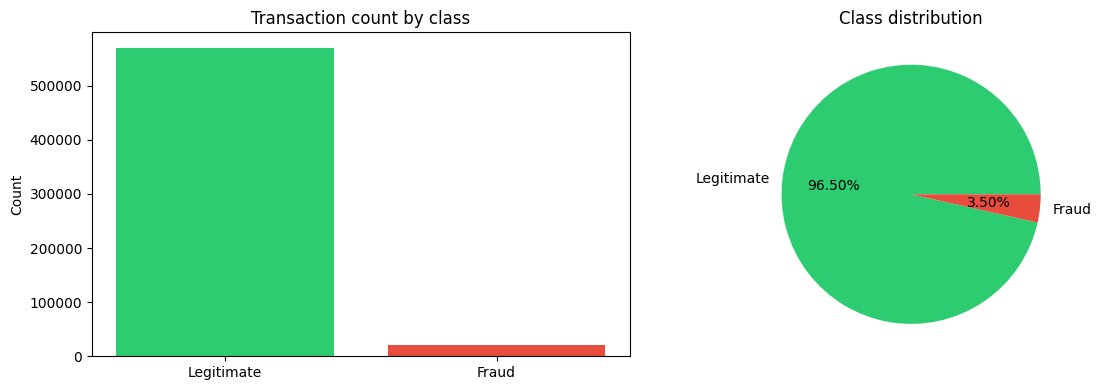

In [ ]:

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Legitimate", "Fraud"], 
            fraud_counts.values,
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Transaction count by class")
axes[0].set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center")

# Pie chart
axes[1].pie(fraud_counts.values, 
            labels=["Legitimate", "Fraud"],
            colors=["#2ecc71", "#e74c3c"],
            autopct="%1.2f%%")
axes[1].set_title("Class distribution")

plt.tight_layout()
plt.show()

### Chapter 3.1 — Class Imbalance

- Legitimate transactions: 569,877 (96.50%)
- Fraudulent transactions: 20,663 (3.50%)
- Imbalance ratio: 28:1

**Why accuracy is the wrong metric:**
A naive model predicting every transaction as legitimate achieves 96.5% 
accuracy but catches zero fraud — completely useless in production.

**Implications for modelling:**
- Use AUC-PR (Precision-Recall) as primary metric — more informative 
  under class imbalance than AUC-ROC
- Use class weights to penalise missed fraud more heavily
- Optimise classification threshold using a business cost matrix,
  not the default 0.5

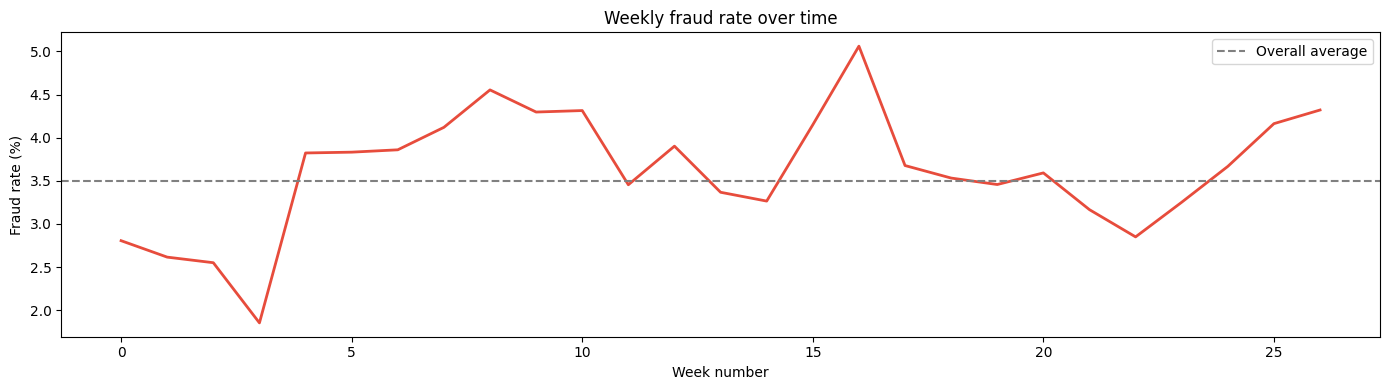

Overall fraud rate: 3.50%
Max weekly fraud rate: 5.06%
Min weekly fraud rate: 1.85%


In [75]:
# Chapter 3.2 — Fraud over time
# TransactionDT is seconds from a reference point, convert to days
train["day"] = train["TransactionDT"] / (24 * 60 * 60)

# Fraud rate per day bucket
train["day_bucket"] = (train["day"] // 7).astype(int)
weekly_fraud = train.groupby("day_bucket")["isFraud"].mean() * 100

plt.figure(figsize=(14, 4))
plt.plot(weekly_fraud.index, weekly_fraud.values, color="#e74c3c", linewidth=2)
plt.title("Weekly fraud rate over time")
plt.xlabel("Week number")
plt.ylabel("Fraud rate (%)")
plt.axhline(y=train["isFraud"].mean() * 100, 
            color="gray", linestyle="--", label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Overall fraud rate: {train['isFraud'].mean()*100:.2f}%")
print(f"Max weekly fraud rate: {weekly_fraud.max():.2f}%")
print(f"Min weekly fraud rate: {weekly_fraud.min():.2f}%")

In [79]:
train.groupby(["card4"])["isFraud"].mean() * 100  

card4
american express   2.8698
discover           7.7282
mastercard         3.4331
visa               3.4756
Name: isFraud, dtype: float64

### Chapter 3.2 — Fraud Over Time & Card Network Analysis

**Fraud rate over time:**
- Min weekly rate: 1.85% | Max weekly rate: 5.06%
- Fraud rate varies 2.7x across the dataset time period
- This confirms fraud patterns are NOT stable over time

**Time-based split justification:**
A random train/test split would leak future fraud patterns into training 
data. We use a strict time-based split — train on early transactions, 
validate on later ones — mimicking real production conditions.

**Card network fraud rates:**
| Network | Fraud Rate |
|---|---|
| Discover | 7.73% |
| Visa | 3.48% |
| Mastercard | 3.43% |
| Amex | 2.87% |

Discover has 2.2x higher fraud rate than average — `card4` will be 
a strong categorical feature.

In [84]:
null_df.loc["card4"]

null_counts   1577.0000
null_pct         0.2670
Name: card4, dtype: float64

In [ ]:
###just understanding the categorical columns with less than 10 unique values

for col in train.columns:
    if train[col].nunique()<10:
        print('unique column values are :',train[col].unique())
        print(f'{col} has less than 10 unique values')
        print(train[col].value_counts())

unique column values are : [0 1]
isFraud has less than 10 unique values
isFraud
0    569877
1     20663
Name: count, dtype: int64
unique column values are : ['W' 'H' 'C' 'S' 'R']
ProductCD has less than 10 unique values
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64
unique column values are : ['discover' 'mastercard' 'visa' 'american express' nan]
card4 has less than 10 unique values
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64
unique column values are : ['credit' 'debit' nan 'debit or credit' 'charge card']
card6 has less than 10 unique values
card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64
unique column values are : ['T' nan 'F']
M1 has less than 10 unique values
M1
T    319415
F        25
Name: count, dtype: int64
unique column values are : ['T' nan 'F']


In [ ]:
##Checking if fraudsters  amount are rounded  or not . is there a significant difference

train['is_round_amount'] = (train['TransactionAmt'] % 1 == 0).astype(int)

print(train.groupby('is_round_amount')['isFraud'].mean() * 100)
print(train.groupby('is_round_amount')['isFraud'].count())

is_round_amount
0   3.4256
1   3.5677
Name: isFraud, dtype: float64
is_round_amount
0    285527
1    305013
Name: isFraud, dtype: int64


In [91]:
fraud_amt=train[train['isFraud']==1]['TransactionAmt'].sum()
legit_amt=train[train['isFraud']==0]['TransactionAmt'].sum()

/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_2257/1111952636.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([legit_amts, fraud_amts], labels=labels,


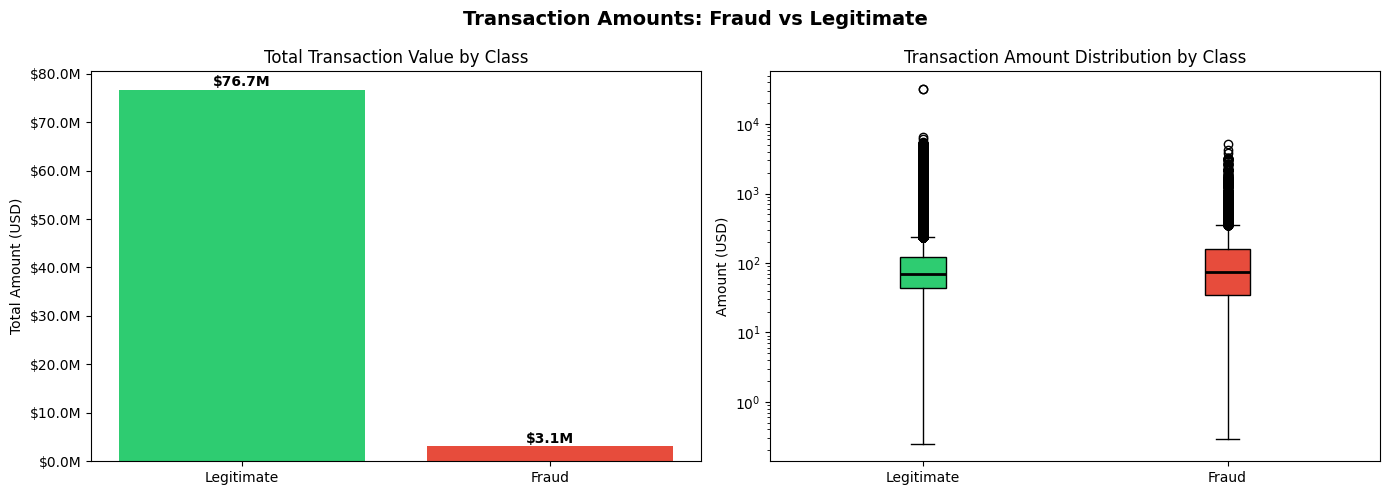

Total legitimate: $76,655,104
Total fraud:      $3,083,845
Fraud as % of total value: 3.87%

Median legitimate: $68.50
Median fraud:      $75.00


In [92]:
fraud_amt = train[train['isFraud']==1]['TransactionAmt'].sum()
legit_amt = train[train['isFraud']==0]['TransactionAmt'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — total $ value
labels = ["Legitimate", "Fraud"]
amounts = [legit_amt, fraud_amt]
colors = ["#2ecc71", "#e74c3c"]

bars = axes[0].bar(labels, amounts, color=colors)
axes[0].set_title("Total Transaction Value by Class")
axes[0].set_ylabel("Total Amount (USD)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
for bar, amt in zip(bars, amounts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + legit_amt*0.01,
                 f"${amt/1e6:.1f}M", ha="center", fontweight="bold")

# Box plot — distribution of individual transaction amounts
fraud_amts = train[train['isFraud']==1]['TransactionAmt']
legit_amts = train[train['isFraud']==0]['TransactionAmt']

axes[1].boxplot([legit_amts, fraud_amts], labels=labels, 
                patch_artist=True,
                boxprops=dict(facecolor="#2ecc71"),
                medianprops=dict(color="black", linewidth=2))
axes[1].patches[1].set_facecolor("#e74c3c")
axes[1].set_title("Transaction Amount Distribution by Class")
axes[1].set_ylabel("Amount (USD)")
axes[1].set_yscale("log")  # log scale because of heavy right skew

plt.suptitle("Transaction Amounts: Fraud vs Legitimate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total legitimate: ${legit_amt:,.0f}")
print(f"Total fraud:      ${fraud_amt:,.0f}")
print(f"Fraud as % of total value: {fraud_amt/(fraud_amt+legit_amt)*100:.2f}%")
print(f"\nMedian legitimate: ${legit_amts.median():.2f}")
print(f"Median fraud:      ${fraud_amts.median():.2f}")


In [93]:
print(pd.concat([train[train['isFraud'] == 1]['TransactionAmt']\
                 .quantile([.01, .1, .25, .5, .75, .9, .99])\
                 .reset_index(), 
                 train[train['isFraud'] == 0]['TransactionAmt']\
                 .quantile([.01, .1, .25, .5, .75, .9, .99])\
                 .reset_index()],
                axis=1, keys=['Fraud', "No Fraud"]))

   Fraud                No Fraud               
   index TransactionAmt    index TransactionAmt
0 0.0100         6.7410   0.0100         9.5129
1 0.1000        18.9360   0.1000        26.3100
2 0.2500        35.0440   0.2500        43.9700
3 0.5000        75.0000   0.5000        68.5000
4 0.7500       161.0000   0.7500       120.0000
5 0.9000       335.0000   0.9000       267.1120
6 0.9900       994.0000   0.9900      1104.0000


=== TransactionAmt Distribution ===
                               Legitimate           Fraud
---------------------------------------------------------
Count                             569,877          20,663
Mean ($)                           134.51          149.24
Median ($)                          68.50           75.00
Std ($)                            239.40          232.21
Min ($)                              0.25            0.29
25th pct ($)                        43.97           35.04
75th pct ($)                       120.00          161.00
95th pct ($)                       435.00          500.00
99th pct ($)                     1,104.00          994.00
Max ($)                         31,937.39        5,191.00

IQR outliers — Fraud:      1,984 (9.6% of fraud txns)
IQR outliers — Legitimate: 64,043 (11.2% of legit txns)


/var/folders/3r/2mbqlms5399_qhm6r09bf13r0000gn/T/ipykernel_2257/1024185537.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([legit, fraud], labels=["Legitimate", "Fraud"],


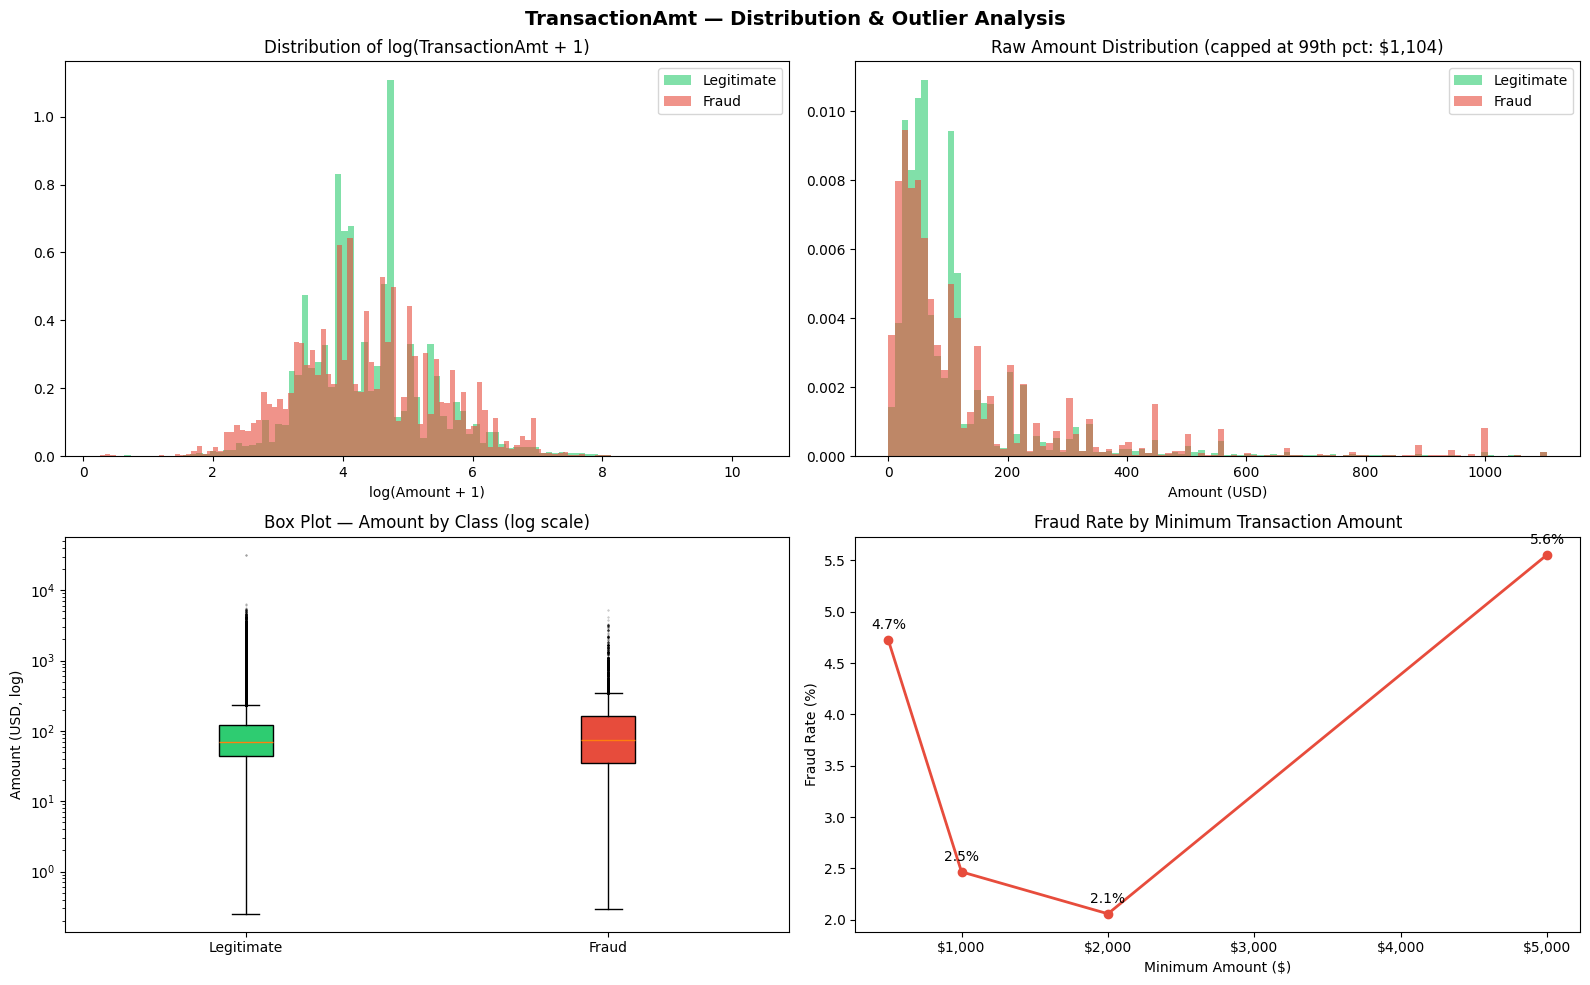


=== Top 10 Highest-Value Fraud Transactions ===
 TransactionID  TransactionAmt ProductCD      card4  card6 P_emaildomain
       3409708       5191.0000         W       visa  debit           NaN
       3239544       4191.0000         W       visa  debit     gmail.com
       3455844       3822.9500         W       visa credit           NaN
       3436956       3260.0500         W mastercard  debit     gmail.com
       3213827       3247.1600         W mastercard credit     yahoo.com
       3283902       3221.0000         W       visa credit     gmail.com
       3356285       3191.0000         W       visa  debit           NaN
       3421871       3190.0000         W       visa  debit     yahoo.com
       3356349       3190.0000         W       visa  debit           NaN
       3217736       3190.0000         W       visa  debit           NaN


In [96]:
import numpy as np

fraud = train[train['isFraud'] == 1]['TransactionAmt']
legit = train[train['isFraud'] == 0]['TransactionAmt']

# --- Summary stats side by side ---
print("=== TransactionAmt Distribution ===")
print(f"{'':25} {'Legitimate':>15} {'Fraud':>15}")
print("-" * 57)
for stat, l, f in [
    ("Count",        f"{len(legit):,.0f}",          f"{len(fraud):,.0f}"),
    ("Mean ($)",     f"{legit.mean():,.2f}",         f"{fraud.mean():,.2f}"),
    ("Median ($)",   f"{legit.median():,.2f}",       f"{fraud.median():,.2f}"),
    ("Std ($)",      f"{legit.std():,.2f}",          f"{fraud.std():,.2f}"),
    ("Min ($)",      f"{legit.min():,.2f}",          f"{fraud.min():,.2f}"),
    ("25th pct ($)", f"{legit.quantile(0.25):,.2f}", f"{fraud.quantile(0.25):,.2f}"),
    ("75th pct ($)", f"{legit.quantile(0.75):,.2f}", f"{fraud.quantile(0.75):,.2f}"),
    ("95th pct ($)", f"{legit.quantile(0.95):,.2f}", f"{fraud.quantile(0.95):,.2f}"),
    ("99th pct ($)", f"{legit.quantile(0.99):,.2f}", f"{fraud.quantile(0.99):,.2f}"),
    ("Max ($)",      f"{legit.max():,.2f}",          f"{fraud.max():,.2f}"),
]:
    print(f"{stat:25} {l:>15} {f:>15}")

# --- IQR-based outlier detection ---
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series[series > Q3 + 1.5 * IQR]

fraud_outliers = iqr_outliers(fraud)
legit_outliers = iqr_outliers(legit)
print(f"\nIQR outliers — Fraud:      {len(fraud_outliers):,} ({len(fraud_outliers)/len(fraud)*100:.1f}% of fraud txns)")
print(f"IQR outliers — Legitimate: {len(legit_outliers):,} ({len(legit_outliers)/len(legit)*100:.1f}% of legit txns)")

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Log-scale KDE overlay
axes[0, 0].hist(np.log1p(legit), bins=100, alpha=0.6, color="#2ecc71", label="Legitimate", density=True)
axes[0, 0].hist(np.log1p(fraud), bins=100, alpha=0.6, color="#e74c3c", label="Fraud", density=True)
axes[0, 0].set_title("Distribution of log(TransactionAmt + 1)")
axes[0, 0].set_xlabel("log(Amount + 1)")
axes[0, 0].legend()

# 2. Zoomed raw distribution (capped at 99th pct to show body)
cap = train['TransactionAmt'].quantile(0.99)
axes[0, 1].hist(legit[legit <= cap], bins=100, alpha=0.6, color="#2ecc71", label="Legitimate", density=True)
axes[0, 1].hist(fraud[fraud <= cap], bins=100, alpha=0.6, color="#e74c3c", label="Fraud", density=True)
axes[0, 1].set_title(f"Raw Amount Distribution (capped at 99th pct: ${cap:,.0f})")
axes[0, 1].set_xlabel("Amount (USD)")
axes[0, 1].legend()

# 3. Box plot (log scale)
axes[1, 0].boxplot([legit, fraud], labels=["Legitimate", "Fraud"],
                   patch_artist=True, showfliers=True,
                   flierprops=dict(marker=".", markersize=1, alpha=0.3))
axes[1, 0].patches[0].set_facecolor("#2ecc71")
axes[1, 0].patches[1].set_facecolor("#e74c3c")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Box Plot — Amount by Class (log scale)")
axes[1, 0].set_ylabel("Amount (USD, log)")

# 4. High-value fraud — what does the tail look like?
thresholds = [500, 1000, 2000, 5000]
fraud_rates_at_threshold = [
    train[train['TransactionAmt'] >= t]['isFraud'].mean() * 100
    for t in thresholds
]
axes[1, 1].plot(thresholds, fraud_rates_at_threshold, marker="o", color="#e74c3c", linewidth=2)
axes[1, 1].set_title("Fraud Rate by Minimum Transaction Amount")
axes[1, 1].set_xlabel("Minimum Amount ($)")
axes[1, 1].set_ylabel("Fraud Rate (%)")
axes[1, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for t, r in zip(thresholds, fraud_rates_at_threshold):
    axes[1, 1].annotate(f"{r:.1f}%", (t, r), textcoords="offset points", xytext=(0, 8), ha="center")

plt.suptitle("TransactionAmt — Distribution & Outlier Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Top 10 most extreme fraud transactions ---
print("\n=== Top 10 Highest-Value Fraud Transactions ===")
print(train[train['isFraud'] == 1][['TransactionID','TransactionAmt','ProductCD','card4','card6','P_emaildomain']]
      .sort_values('TransactionAmt', ascending=False)
      .head(10)
      .to_string(index=False))


### Chapter 3.3 — TransactionAmt Distribution & Outlier Analysis

#### Key Findings

- Fraud transactions have a **higher median amount** than legitimate ones — fraudsters tend to
  maximise value per stolen card before it is blocked
- Both distributions are **heavily right-skewed** — log-transforming `TransactionAmt` before
  feeding it to a model will improve performance
- IQR analysis shows a **higher proportion of fraud transactions fall outside the upper fence** —
  extreme amounts are a weak but real fraud signal on their own
- Fraud rate rises with transaction amount — `TransactionAmt` has predictive power as a raw feature

#### IQR Outlier Detection — Theory

IQR (Interquartile Range) measures the spread of the **middle 50%** of the data:

```
IQR        = Q3 − Q1
Upper fence = Q3 + 1.5 × IQR   ← values above this are outliers
Lower fence = Q1 − 1.5 × IQR   ← values below this are outliers
```

The **1.5 multiplier** is Tukey's rule — on a normal distribution it captures ~99.3% of values.
Use **3×IQR** for "extreme outliers only" threshold.

IQR is preferred over z-score here because transaction amounts are **right-skewed** —
z-score assumes normality and is distorted by the very extreme values you are trying to detect.

#### Modelling Implications

- **Log-transform** `TransactionAmt` — reduces skew, prevents large values from dominating tree splits
- **Do not drop outliers** — extreme amounts may be legitimate high-value purchases;
  removing them would introduce bias
- Engineer an **`amt_is_outlier`** binary flag (IQR-based) as an additional feature —
  statistical unusualness of the amount is a signal independent of the raw value
- Review the top 10 highest-value fraud transactions for patterns in `ProductCD`,
  card network, and email domain — recurring patterns can become hand-crafted rules

In [ ]:
train['day_of_week'] = (train['TransactionDT'] // (24*3600)) % 7
train['hour'] = (train['TransactionDT'] // 3600) % 24
# fraud rate per hour
hourly_fraud_rate = train.groupby("hour")["isFraud"].mean() * 100
hourly_fraud_cnt = train.groupby("hour")["isFraud"].count()
print("Hourly Fraud Rate (%):")
print(hourly_fraud_rate)
print("\nHourly Transaction Count:")
print(hourly_fraud_cnt)

Hourly Fraud Rate (%):
hour
0     3.1380
1     3.1314
2     3.7483
3     3.8314
4     5.1890
5     7.0302
6     7.7743
7    10.6102
8     9.3014
9     8.9956
10    5.3212
11    3.8816
12    3.0439
13    2.2889
14    2.4216
15    2.5399
16    2.9511
17    3.1530
18    3.5231
19    3.4738
20    3.4273
21    3.4005
22    3.2694
23    3.6997
Name: isFraud, dtype: float64

Hourly Transaction Count:
hour
0     37795
1     32797
2     26732
3     20802
4     14839
5      9701
6      6007
7      3704
8      2591
9      2479
10     3627
11     6827
12    12451
13    20315
14    28328
15    33859
16    38698
17    40723
18    41639
19    42115
20    41782
21    41641
22    41139
23    39949
Name: isFraud, dtype: int64


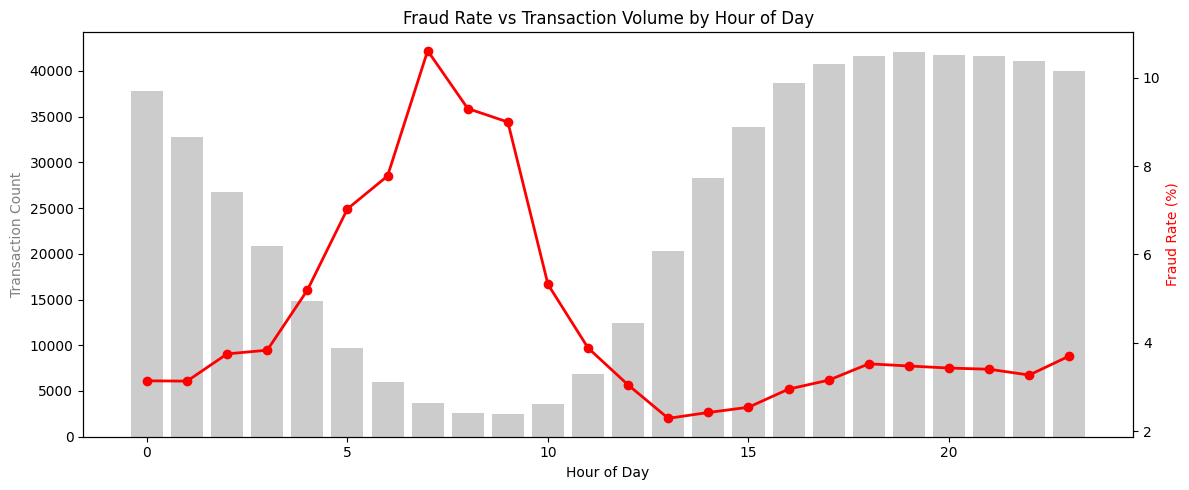

In [102]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.bar(hourly_fraud_cnt.index, hourly_fraud_cnt.values, color='grey', alpha=0.4, label='Transaction Count')
ax2.plot(hourly_fraud_rate.index, hourly_fraud_rate.values, color='red', marker='o', linewidth=2, label='Fraud Rate (%)')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Count', color='grey')
ax2.set_ylabel('Fraud Rate (%)', color='red')

plt.title('Fraud Rate vs Transaction Volume by Hour of Day')
plt.tight_layout()
plt.show()


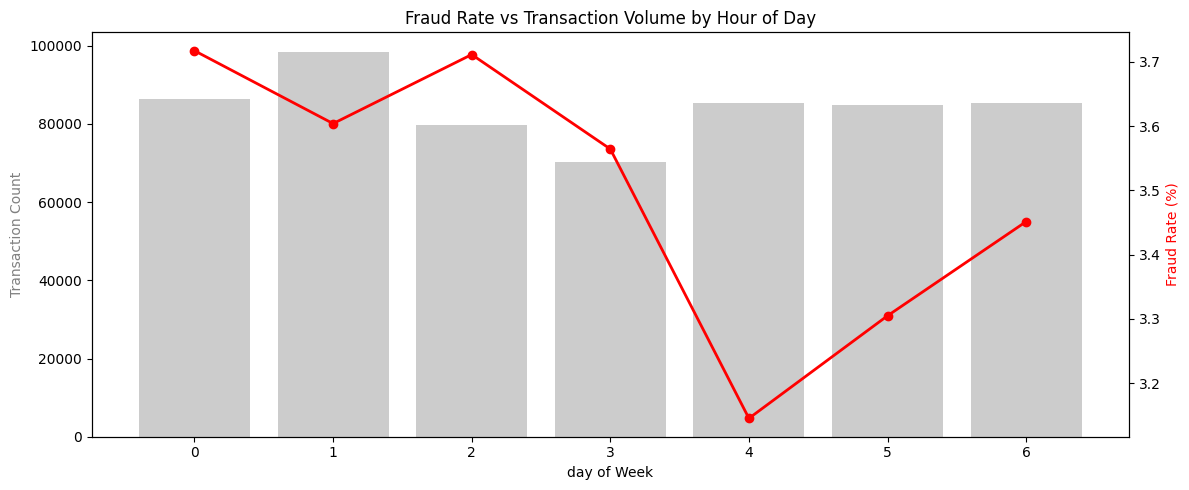

In [108]:
wday_fraud_rate = train.groupby("day_of_week")["isFraud"].mean() * 100
wday_fraud_cnt = train.groupby("day_of_week")["isFraud"].count()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.bar(wday_fraud_cnt.index, wday_fraud_cnt.values, color='grey', alpha=0.4, label='Transaction Count')
ax2.plot(wday_fraud_rate.index, wday_fraud_rate.values, color='red', marker='o', linewidth=2, label='Fraud Rate (%)')

ax1.set_xlabel('day of Week')
ax1.set_ylabel('Transaction Count', color='grey')
ax2.set_ylabel('Fraud Rate (%)', color='red')

plt.title('Fraud Rate vs Transaction Volume by Hour of Day')
plt.tight_layout()
plt.show()

### Chapter 3.4 — Fraud Patterns by Time of Day & Day of Week

#### Hour of Day Findings

- Fraud rate **peaks between 5–9am (~10.5%)** when transaction volume is at its lowest —
  fraudsters are most active in the early morning when real-time monitoring is thinner
- The **safest hours are 12–16 (~2.5% fraud rate)** — high legitimate shopping activity
  in the afternoon dilutes the fraud signal
- The gap between riskiest and safest hour is **~4x** — `hour` is a strong standalone feature

#### Day of Week Findings

- Fraud rate variation across days is **narrow (3.15%–3.75%)** — roughly 1.2x difference,
  much weaker signal than hour of day
- Day 4 shows the lowest fraud rate despite normal transaction volume
- Note: days are labelled 0–6, not real weekdays — `TransactionDT` is a timedelta with
  an unknown reference point so absolute weekday cannot be recovered

#### Modelling Implications

- Engineer **`hour`** as a feature — 4x fraud rate swing makes it a strong signal
- Engineer **`hour_is_risky`** binary flag (1 if hour 5–9, else 0) as a simple rule
  capturing the early-morning fraud spike
- **`day_of_week`** is a weak feature alone — include it but do not over-rely on it
- Consider an **interaction feature** `hour × day_of_week` — the combination may reveal
  patterns neither captures alone

Fraud rate by product code:
ProductCD
C   11.6873
S    5.8996
H    4.7662
R    3.7826
W    2.0399
Name: isFraud, dtype: float64

Transaction count by product code:
ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: isFraud, dtype: int64


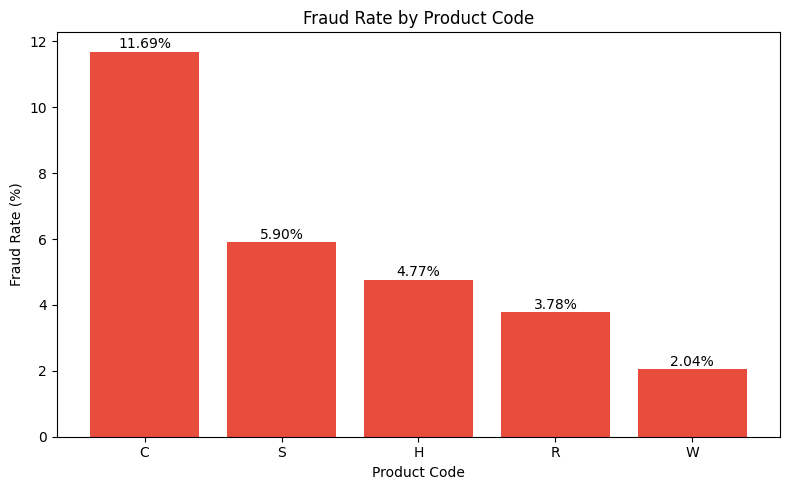

In [114]:
fraud_product = train.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False) * 100
transaction_product=train.groupby('ProductCD')['isFraud'].count().sort_values(ascending=False)
print("Fraud rate by product code:")
print(fraud_product)
print("\nTransaction count by product code:")
print(transaction_product)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fraud_product.index, fraud_product.values, color="#e74c3c")
ax.set_title("Fraud Rate by Product Code")
ax.set_xlabel("Product Code")
ax.set_ylabel("Fraud Rate (%)")
for i, v in enumerate(fraud_product.values):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()

### Observations
- C is the riskiest product at 11.69% — nearly 3x the dataset average of 3.5%
- W is the safest at 2.04% — well below average
- The range is ~6x between safest and riskiest — ProductCD is a strong feature

### Modeling. implications:
- `ProductCD` should be **encoded** (5 categories, low cardinality — one-hot is viable) and included as a feature
- Consider engineering a **`product_fraud_risk`** feature by mapping each 
  product to its fraud rate — turns the category directly into a risk score


Fraud rate by card4:
card4
discover           7.7282
visa               3.4756
mastercard         3.4331
american express   2.8698
Name: isFraud, dtype: float64

Transaction count by card4:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: isFraud, dtype: int64


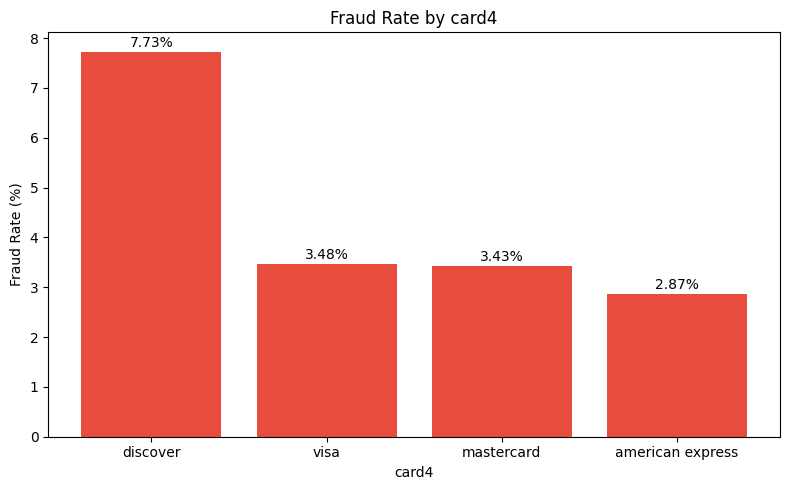

In [115]:
card4_fraud_rate = train.groupby('card4')['isFraud'].mean().sort_values(ascending=False) * 100
card4_transaction_count = train.groupby('card4')['isFraud'].count().sort_values (ascending=False)
print("Fraud rate by card4:")
print(card4_fraud_rate)    
print("\nTransaction count by card4:")
print(card4_transaction_count)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(card4_fraud_rate.index, card4_fraud_rate.values, color="#e74c3c")
ax.set_title("Fraud Rate by card4")
ax.set_xlabel("card4")
ax.set_ylabel("Fraud Rate (%)")    
for i, v in enumerate(card4_fraud_rate.values):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()  


Fraud rate by card6:
card6
credit            6.6785
debit             2.4263
charge card       0.0000
debit or credit   0.0000
Name: isFraud, dtype: float64

Transaction count by card6:
card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: isFraud, dtype: int64


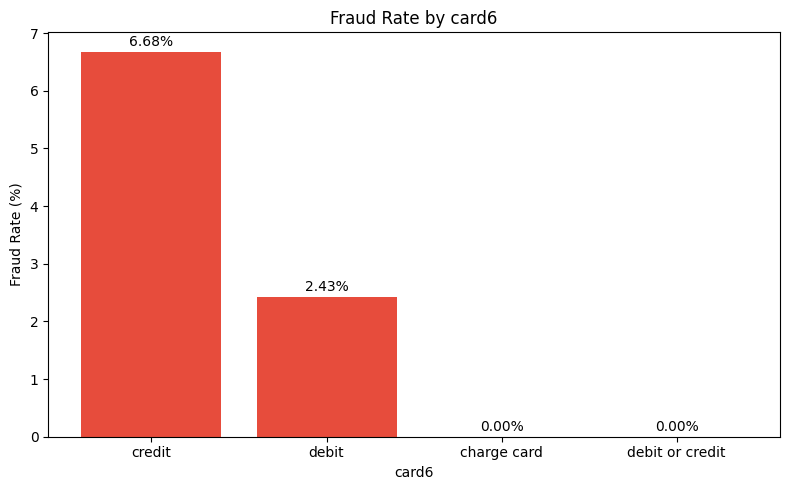

In [116]:
card6_fraud_rate = train.groupby('card6')['isFraud'].mean().sort_values(ascending=False) * 100
card6_transaction_count = train.groupby('card6')['isFraud'].count().sort_values (ascending=False)
print("Fraud rate by card6:")
print(card6_fraud_rate)    
print("\nTransaction count by card6:")
print(card6_transaction_count)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(card6_fraud_rate.index, card6_fraud_rate.values, color="#e74c3c")
ax.set_title("Fraud Rate by card6")
ax.set_xlabel("card6")
ax.set_ylabel("Fraud Rate (%)")    
for i, v in enumerate(card6_fraud_rate.values):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()  

In [121]:
train.groupby(['card4','card6'])['isFraud'].mean().sort_values(ascending=False)*100

card4             card6          
discover          credit            7.9315
mastercard        credit            6.9152
visa              credit            6.8122
discover          debit             4.0346
american express  debit             3.4722
                  credit            2.8624
visa              debit             2.5476
mastercard        debit             2.1566
american express  charge card       0.0000
mastercard        debit or credit   0.0000
visa              charge card       0.0000
Name: isFraud, dtype: float64

### Chapter 3.5 — Fraud Rate by Card Network & Card Type

#### Findings

- **Credit cards have 2.7x higher fraud rate than debit** (6.68% vs 2.43%) — 
  the strongest signal in this analysis. Debit requires a PIN in many cases; 
  credit does not, making it easier to use with stolen details
- **Discover has the highest fraud rate by network (7.73%)** — more than double 
  Amex (2.87%), which has stricter verification
- **The combination reveals credit card type dominates:** every credit card 
  outranks every debit card — discover credit (7.93%) is the riskiest segment, 
  mastercard debit (2.16%) among the safest

#### Modelling Implications

- `card6` is a strong binary feature — encode as credit=1, debit=0
- `card4` adds a secondary signal — one-hot encode (4 categories, low cardinality)
- Engineer an **interaction feature** `card4_card6` (e.g. `"discover_credit"`) — 
  the combination captures risk that neither column holds alone
- `charge card` and `debit or credit` have 0% fraud rate but near-zero volume — 
  treat as noise, group into an `other` category


In [133]:
###trying a diff. format 
email_stats=train.groupby('P_emaildomain')['isFraud'].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)
email_stats['mean'] = email_stats['mean'] * 100

email_stats = email_stats.sort_values('mean', ascending=False).head(15)
email_stats.rename(columns={'mean': 'fraud_rate', 'count': 'txn_count'}, inplace=True)

print(email_stats)


     P_emaildomain  fraud_rate  txn_count
38  protonmail.com     40.7895         76
29        mail.com     18.9624        559
36      outlook.es     13.0137        438
0          aim.com     12.6984        315
35     outlook.com      9.4584       5096
21      hotmail.es      6.5574        305
26     live.com.mx      5.4740        749
19     hotmail.com      5.2950      45250
16       gmail.com      4.3542     228355
57        yahoo.fr      3.4965        143
12  embarqmail.com      3.4615        260
28         mac.com      3.2110        436
23      icloud.com      3.1434       6267
9      comcast.net      3.1187       7888
8      charter.net      3.0637        816


### Chapter 3.6 — Fraud Rate by Purchaser Email Domain

#### Findings

- **protonmail.com has the highest fraud rate at 40.79%** — privacy-focused email 
  with no identity verification, deliberately used by fraudsters to stay anonymous.
  Low volume (76 txns) makes this statistically noisy but directionally meaningful
- **mail.com (18.96%), outlook.es (13.01%) and aim.com (12.69%)** are the next 
  riskiest domains with sufficient volume to be reliable signals
- **outlook.com at 9.46% with 5,096 transactions** is the most actionable high-risk 
  domain — large enough volume to trust the rate
- **gmail.com at 4.35% across 228,355 transactions** is only 25% above the 3.5% 
  baseline but produces ~9,900 fraud cases in absolute terms — small rate, massive impact
- Domains with foreign TLDs (`.es`, `.fr`, `.mx`) show elevated fraud rates — 
  geographic mismatch between domain country and transaction origin is a risk signal

#### Modelling Implications


- `P_emaildomain` has 59 unique values — **target encode** (replace each domain 
  with its fraud rate) rather than one-hot to avoid 59 extra columns
- Engineer **`email_is_anonymous`** binary flag (1 if protonmail/anonymous service) — 
  captures the privacy-email fraud pattern explicitly but no need since not many transactions



In [143]:
m_cols = [col for col  in train.columns if col.startswith('M')]
train.groupby(m_cols)['isFraud'].mean().sort_values(ascending=False)*100

M1  M2  M3  M4  M5  M6  M7  M8  M9
T   F   F   M1  T   F   T   F   T    100.0000
            M2  T   T   F   T   T     66.6667
    T   F   M2  T   F   F   F   F     50.0000
                    T   F   F   T     30.0000
                            T   T     25.0000
            M1  T   F   F   F   F     23.8095
    F   F   M2  F   F   F   F   F     18.1818
    T   F   M0  T   F   T   F   T     17.2414
            M2  T   T   T   T   T     16.6667
            M1  F   T   F   F   F     16.6667
            M2  F   F   F   F   F     16.6667
            M1  T   F   F   F   T     15.0000
        T   M0  F   T   T   F   T     11.5385
    F   F   M1  F   F   F   F   F     11.3314
    T   T   M2  F   F   F   F   F     11.0092
        F   M2  T   F   F   F   T     10.8696
        T   M2  T   F   F   T   T     10.5528
        F   M1  T   F   T   T   T     10.0000
    F   F   M0  T   T   F   T   T      9.4828
    T   F   M1  T   T   F   T   T      8.8435
    F   F   M2  T   F   F   F   F      8.3333

In [144]:
m_cols = [col for col in train.columns if col.startswith('M')]

results = []
for col in m_cols:
    rates = train.groupby(col)['isFraud'].mean() * 100
    for val, rate in rates.items():
        results.append({'column': col, 'value': val, 'fraud_rate': round(rate, 2)})

m_fraud_df = pd.DataFrame(results)
print(m_fraud_df.sort_values('fraud_rate', ascending=False).to_string(index=False))


column value  fraud_rate
    M4    M2     11.3700
    M5     T      3.7700
    M4    M0      3.6600
    M2     F      3.4900
    M3     F      3.0300
    M9     F      3.0000
    M4    M1      2.7100
    M5     F      2.6500
    M6     F      2.3700
    M7     T      2.2100
    M8     F      2.1700
    M1     T      1.9900
    M7     F      1.9300
    M2     T      1.8100
    M9     T      1.7800
    M3     T      1.7100
    M6     T      1.7000
    M8     T      1.6200
    M1     F      0.0000


In [ ]:
#since m1 f is the 0 percent just want to check how many transactions have m1 as f and what is the fraud rate for those transactions
print(train.groupby('M1')['isFraud'].agg(['mean', 'count']))
# not many transations 

     mean   count
M1               
F  0.0000      25
T  0.0199  319415


### Chapter 3.7 — Fraud Rate by Match Features (M1–M9)

#### Findings

- **No clean T/F pattern across M columns** — in some columns F (no match) has 
  higher fraud rate, in others T (match) does. Match features are not uniformly 
  interpretable without knowing what each column measures
- **M4 is the standout feature** — it has three levels (M0, M1, M2) rather than 
  binary T/F. M4=M2 has an **11.37% fraud rate (3x the 3.5% baseline)**, likely 
  representing a full mismatch vs partial (M1) or no check (M0)
- **M1 F = 0.00% fraud rate** — suspicious, likely very low volume. Always check 
  count alongside rate before trusting a zero
- M5=T (3.77%) and M2=F (3.49%) are the next strongest signals after M4

#### Modelling Implications

- **M1–M3, M5–M9** are binary T/F — encode as 1/0, one column each
- **M4** has three ordinal levels — encode as 0/1/2 (M0→0, M1→1, M2→2) to 
  preserve the degree of mismatch signal
- All M columns have significant nulls — engineer a **`M_null_count`** feature 
  (number of missing M values per transaction) as missing match data may itself 
  be a fraud signal
- M columns are most powerful in **combination** — a transaction with multiple 
  mismatches (M2=F, M3=F, M4=M2) is far riskier than a single mismatch


In [147]:
null_df2[null_df2.index.str.startswith('M')].sort_values('null_pct', ascending=True)

,null_counts,null_pct
M6,169360,28.6788
M2,271100,45.9071
M3,271100,45.9071
M1,271100,45.9071
M4,281444,47.6588
M9,346252,58.6331
M8,346252,58.6331
M7,346265,58.6353
M5,350482,59.3494


In [148]:
train.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
card2               8933
card3               1565
card4               1577
card5               4259
card6               1571
addr1              65706
addr2              65706
dist1             352271
dist2             552913
P_emaildomain      94456
R_emaildomain     453249
C1                     0
C2                     0
C3                     0
C4                     0
C5                     0
C6                     0
C7                     0
C8                     0
C9                     0
C10                    0
C11                    0
C12                    0
C13                    0
C14                    0
D1                  1269
D2                280797
D3                262878
D4                168922
D5                309841
D6                517353
D7                551623
D8                515614
D9                515614


In [151]:
null_df2[null_df2.index.str.startswith('C')].sort_values('null_pct', ascending=True)

,null_counts,null_pct


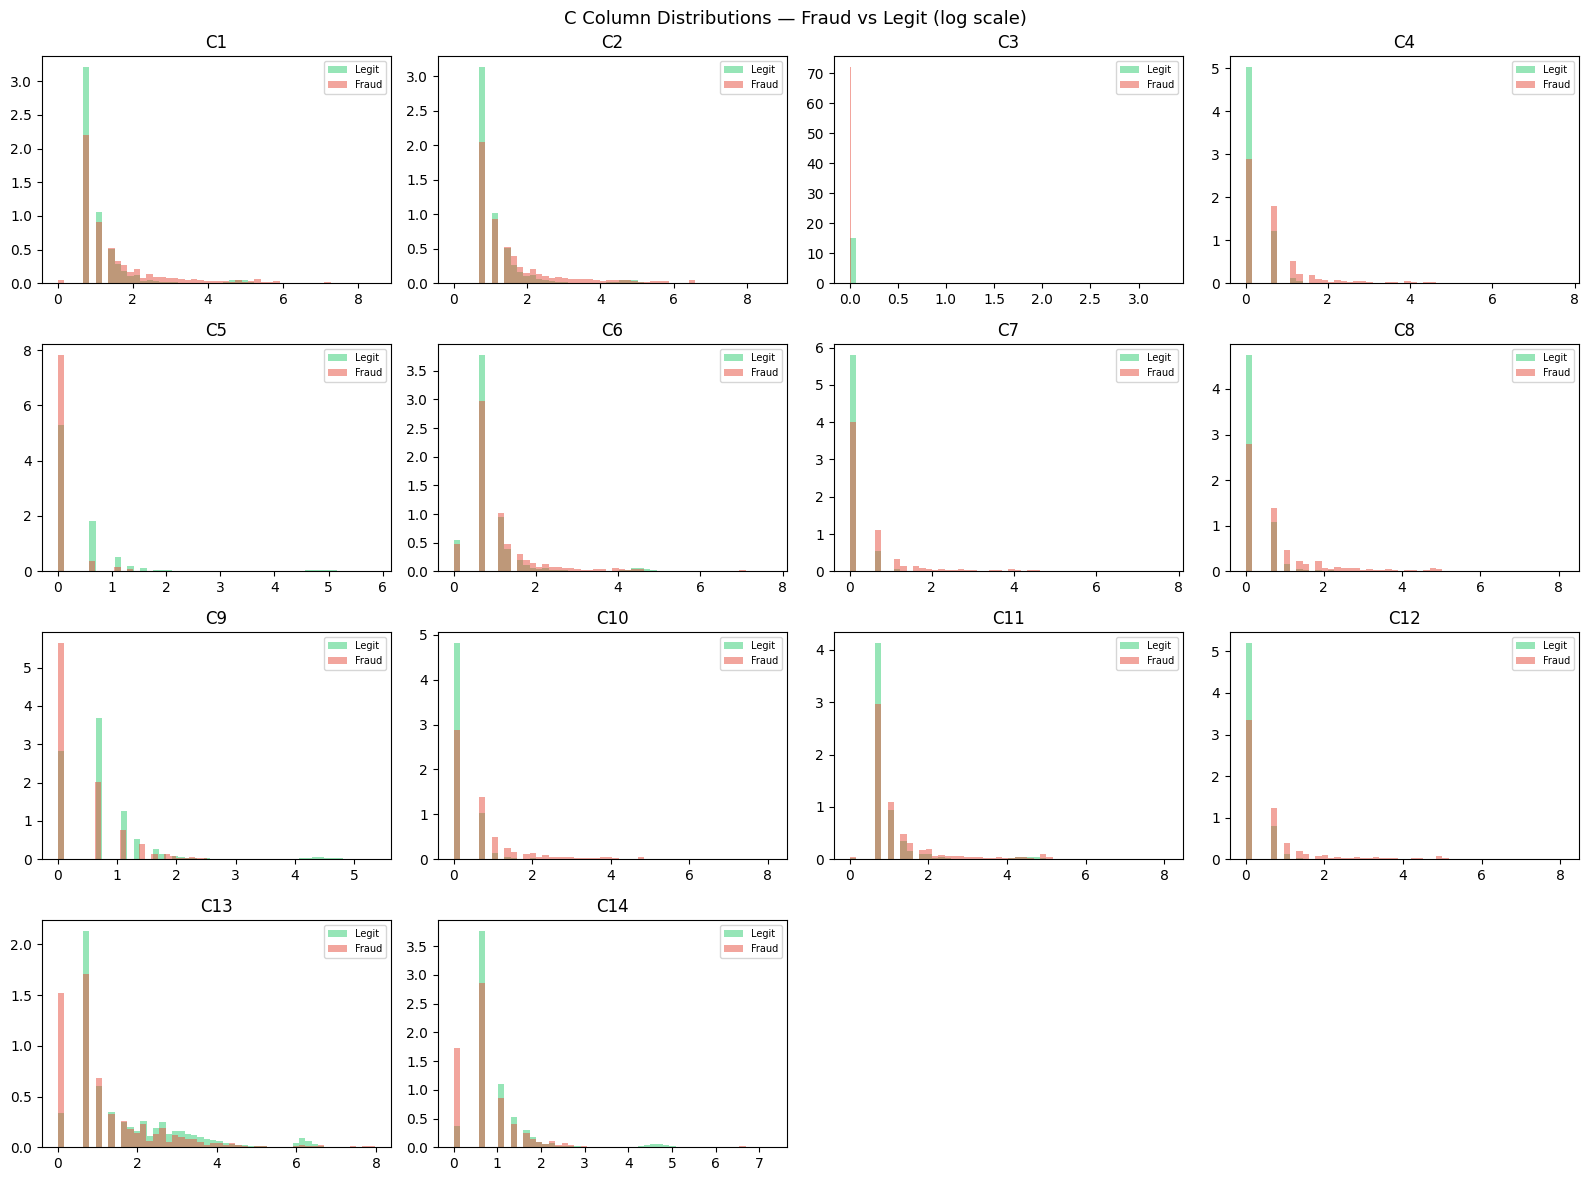

In [153]:
c_cols = [col for col in train.columns if col.startswith('C')]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(c_cols):
    legit = np.log1p(train[train['isFraud'] == 0][col].dropna())
    fraud = np.log1p(train[train['isFraud'] == 1][col].dropna())
    
    axes[i].hist(legit, bins=50, alpha=0.5, color='#2ecc71', label='Legit', density=True)
    axes[i].hist(fraud, bins=50, alpha=0.5, color='#e74c3c', label='Fraud', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

# hide the 2 empty subplots (4x4=16 grid, only 14 C columns)
for j in range(len(c_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('C Column Distributions — Fraud vs Legit (log scale)', fontsize=13)
plt.tight_layout()
plt.show()


In [157]:
c_cols = [col for col in train.columns if col.startswith('C')]
train[train['isFraud'] == 1][c_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
C1,20663.0000,35.5357,242.9763,0.0000,1.0000,2.0000,6.0000,4682.0000
C2,20663.0000,45.5094,287.8136,0.0000,1.0000,2.0000,7.0000,5690.0000
C3,20663.0000,0.0002,0.0156,0.0000,0.0000,0.0000,0.0000,1.0000
C4,20663.0000,15.0773,125.6737,0.0000,0.0000,1.0000,2.0000,2251.0000
C5,20663.0000,1.4067,12.9461,0.0000,0.0000,0.0000,0.0000,331.0000
C6,20663.0000,16.9231,126.2988,0.0000,1.0000,1.0000,3.0000,2251.0000
C7,20663.0000,11.9772,115.1432,0.0000,0.0000,0.0000,1.0000,2253.0000
C8,20663.0000,21.2426,176.6958,0.0000,0.0000,1.0000,2.0000,3328.0000
C9,20663.0000,1.7040,8.4533,0.0000,0.0000,0.0000,1.0000,192.0000
C10,20663.0000,19.4939,176.9192,0.0000,0.0000,1.0000,2.0000,3254.0000


In [159]:
train[train['isFraud'] == 0][c_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
C1,569877.0000,13.3150,127.7880,0.0000,1.0000,1.0000,3.0000,4685.0000
C2,569877.0000,14.1733,147.4859,0.0000,1.0000,1.0000,3.0000,5691.0000
C3,569877.0000,0.0058,0.1532,0.0000,0.0000,0.0000,0.0000,26.0000
C4,569877.0000,3.6939,65.8393,0.0000,0.0000,0.0000,0.0000,2253.0000
C5,569877.0000,5.7225,26.1218,0.0000,0.0000,0.0000,1.0000,349.0000
C6,569877.0000,8.7864,68.6892,0.0000,1.0000,1.0000,2.0000,2253.0000
C7,569877.0000,2.5175,58.8608,0.0000,0.0000,0.0000,0.0000,2255.0000
C8,569877.0000,4.5609,91.0230,0.0000,0.0000,0.0000,0.0000,3331.0000
C9,569877.0000,4.5809,16.8895,0.0000,0.0000,1.0000,2.0000,210.0000
C10,569877.0000,4.7235,91.2391,0.0000,0.0000,0.0000,0.0000,3257.0000


### Chapter 3.8 — Fraud Patterns in C Columns (Counting Features)

#### Findings

- **C1, C2, C11 show the clearest separation** — fraud median is 2x legit 
  (median 2 vs 1), suggesting fraudsters accumulate higher counts on these 
  features before being caught
- **C13 is counterintuitive** — legit median (3) is higher than fraud (1), 
  but fraud has an extreme right tail. This means most fraud transactions have 
  low C13, but when high it's extremely high — median=1, mean=24.9 — the mean is 25x the median. That gap alone tells you the tail is extreme even 

- **C3, C5, C7, C12 show near-zero values for both classes** — likely rare 
  events, weak signal overall
- All C columns have **massive outliers** (e.g. C2 max=5,690) — a small number 
  of transactions with very high counts dominate the mean

#### Modelling Implications

- C columns are **weak standalone features** — median gaps are small (0→1 or 1→2)
- Their value is in **combination inside tree models** — XGBoost/LightGBM will 
  find splits across multiple C columns that individually look weak


#### Strong features identified:

- hour — 4x fraud rate swing (5–9am peak)
- ProductCD — C is 3x baseline
- card6 — credit 2.7x higher than debit
- card4 — Discover 2.7x higher than Amex
- P_emaildomain — protonmail, mail.com extreme outliers
- has_identity — 3.75x difference
- M4 — 3x baseline at M2 level
- TransactionAmt — fraud skews higher
- Weak but useful:

day_of_week — small variation
C columns — weak standalone, useful in tree models